<h1>Import Required Libraries</h1>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

<h1>Load Dataset</h1>

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

<h1>View Dataset</h1>

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

<h1>Understand Dataset</h1>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<h1>Check Missing Values</h1>

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
(df["TotalCharges"]==" ").sum()

np.int64(11)

<h1>Statistical Summary</h1>

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<h1>Target Variable Analysis(Churn)</h1>

In [9]:
#Check Distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

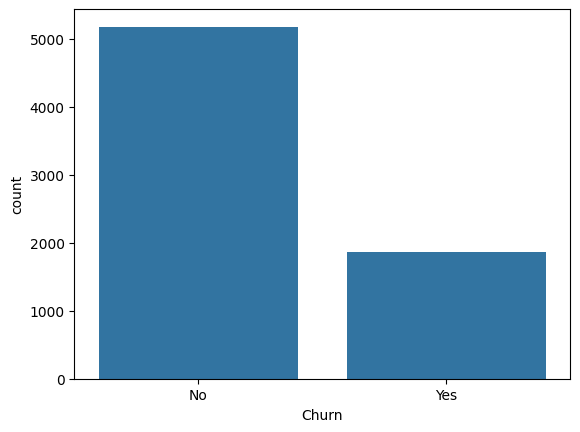

In [10]:
#Visualize Churn
sns.countplot(x="Churn",data=df)
plt.show()

<h1>Contract Type vs Churn</h1>

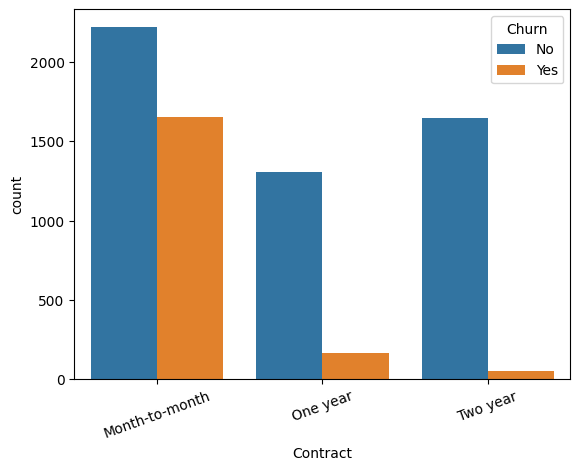

In [11]:
sns.countplot(x="Contract",hue="Churn",data=df)

plt.xticks(rotation=20)

plt.show()

<h1>Monthly Charges Distribution</h1>

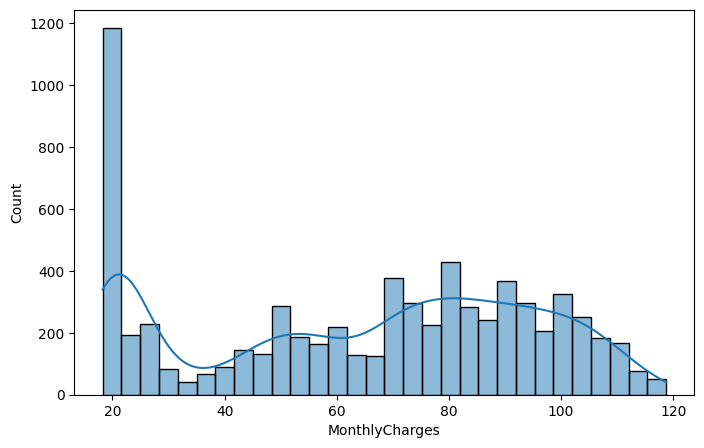

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"],bins=30,kde=True)

plt.show()

<h1>Tenure vs Churn</h1>

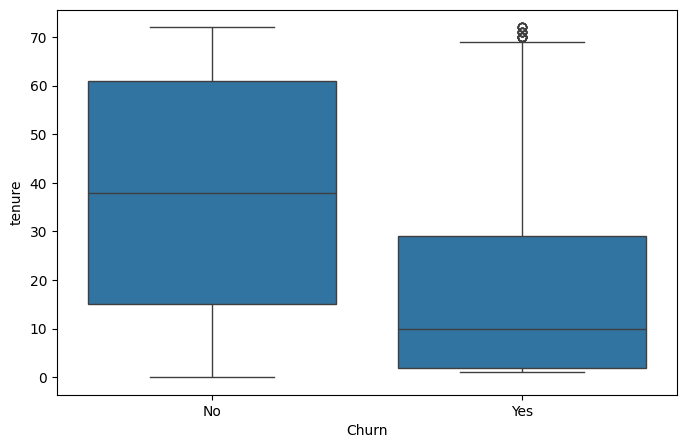

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn",y="tenure",data=df)

plt.show()

<h1>Correlation Analysis</h1>

In [14]:
temp = df.copy()

for col in temp.columns:
    if temp[col].dtype=="object":
        
        temp[col]=temp[col].astype("category").cat.codes

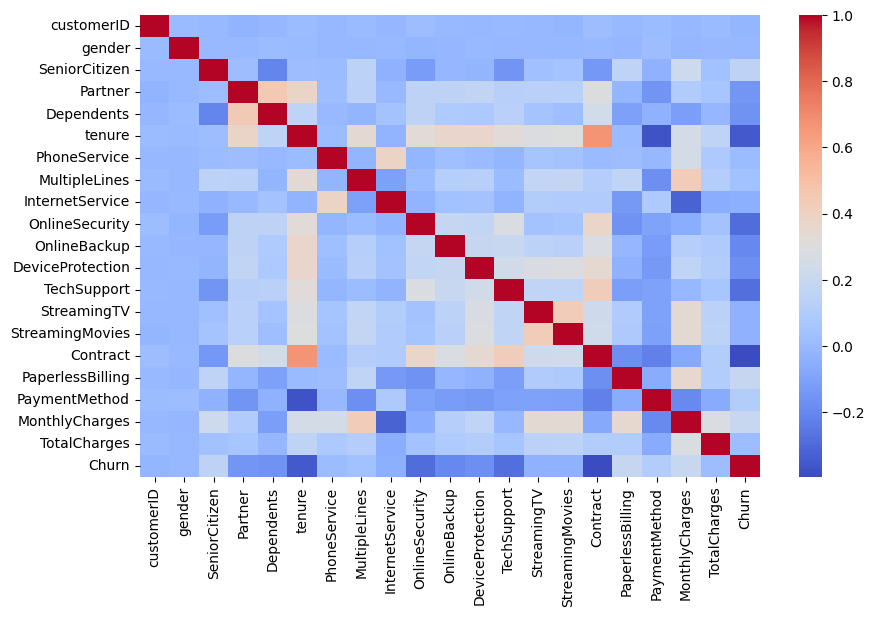

In [15]:
#Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(temp.corr(),cmap="coolwarm")

plt.show()

In [16]:
df.to_csv("cleaned_telco.csv",index=False)

In [17]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",np.nan)

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [19]:
df["TotalCharges"].dtype

dtype('float64')

In [20]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median())

In [21]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [22]:
df.drop(columns=["customerID"],inplace=True)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [25]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

<h1>Encode Categorical Variables</h1>

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype=="object":
        df[col] = le.fit_transform(
            df[col])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


<h1>Feature Engineering</h1>

In [28]:
#Average charge per month
df["AvgChargePerMonth"] = (df["TotalCharges"]/(df["tenure"] + 1))

In [29]:
#Charge Ratio
df["ChargeRatio"] = (df["MonthlyCharges"]/(df["tenure"] + 1))

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   int64  
 1   SeniorCitizen      7043 non-null   int64  
 2   Partner            7043 non-null   int64  
 3   Dependents         7043 non-null   int64  
 4   tenure             7043 non-null   int64  
 5   PhoneService       7043 non-null   int64  
 6   MultipleLines      7043 non-null   int64  
 7   InternetService    7043 non-null   int64  
 8   OnlineSecurity     7043 non-null   int64  
 9   OnlineBackup       7043 non-null   int64  
 10  DeviceProtection   7043 non-null   int64  
 11  TechSupport        7043 non-null   int64  
 12  StreamingTV        7043 non-null   int64  
 13  StreamingMovies    7043 non-null   int64  
 14  Contract           7043 non-null   int64  
 15  PaperlessBilling   7043 non-null   int64  
 16  PaymentMethod      7043 

<h1>Separation of Features and Target</h1>

In [31]:
X = df.drop("Churn",axis=1)
y = df["Churn"]

<h1>Train Test Split</h1>

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
print(X_train.shape)
print(X_test.shape)

(5634, 21)
(1409, 21)


<h1>Feature Scaling</h1>

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
#Importing important Liabraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [36]:
#Train Logistic Regression Model
log_model = LogisticRegression()

log_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
#Pradiction
log_pred = log_model.predict(X_test)

In [38]:
#Accuracy of model
accuracy_score(y_test,log_pred)

0.815471965933286

In [39]:
#Classification Report
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [40]:
#Confusion Matrix
confusion_matrix(y_test,log_pred)

array([[940,  96],
       [164, 209]])

In [41]:
#Random Forest Training
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
#Random Forest Prediction
rf_pred = rf_model.predict(X_test)

In [43]:
#Random Forest Accuracy
accuracy_score(y_test,rf_pred)

0.7842441447835344

In [44]:
#Model Comparision
print("Logistic Accuracy:",accuracy_score(y_test,log_pred))
print("Random Forest Accuracy:",accuracy_score(y_test,rf_pred))

Logistic Accuracy: 0.815471965933286
Random Forest Accuracy: 0.7842441447835344


In [46]:
#Feature importance
importance = rf_model.feature_importances_
features = X.columns
for f,i in zip(features,importance):
    print(f,":",round(i,3))

gender : 0.02
SeniorCitizen : 0.017
Partner : 0.018
Dependents : 0.016
tenure : 0.101
PhoneService : 0.004
MultipleLines : 0.017
InternetService : 0.02
OnlineSecurity : 0.043
OnlineBackup : 0.021
DeviceProtection : 0.016
TechSupport : 0.03
StreamingTV : 0.012
StreamingMovies : 0.013
Contract : 0.061
PaperlessBilling : 0.022
PaymentMethod : 0.04
MonthlyCharges : 0.118
TotalCharges : 0.121
AvgChargePerMonth : 0.115
ChargeRatio : 0.176


In [47]:
#Model Saving
import joblib
joblib.dump(rf_model,"churn_model.pkl")

['churn_model.pkl']